# CSIT 598 - Assignment 1
## 01. MNIST Data Loading and Preprocessing

This notebook:
- Loads MNIST
- Creates train/validation/test splits (50k/10k/10k)
- Builds normalized and standardized features
- Saves artifacts for downstream notebooks

In [9]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from utils import prepare_mnist_splits, RANDOM_STATE

In [10]:
splits = prepare_mnist_splits(random_state=RANDOM_STATE)

X_train = splits['X_train']
X_val = splits['X_val']
X_test = splits['X_test']
X_train_std = splits['X_train_std']
X_val_std = splits['X_val_std']
X_test_std = splits['X_test_std']
y_train = splits['y_train']
y_val = splits['y_val']
y_test = splits['y_test']

print('Shapes:')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

Shapes:
X_train: (50000, 784), y_train: (50000,)
X_val:   (10000, 784), y_val:   (10000,)
X_test:  (10000, 784), y_test:  (10000,)


In [11]:
# Quick class distribution check
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    print(f'Digit {label}: {count}')

Digit 0: 4931
Digit 1: 5627
Digit 2: 4992
Digit 3: 5101
Digit 4: 4874
Digit 5: 4509
Digit 6: 4912
Digit 7: 5209
Digit 8: 4875
Digit 9: 4970


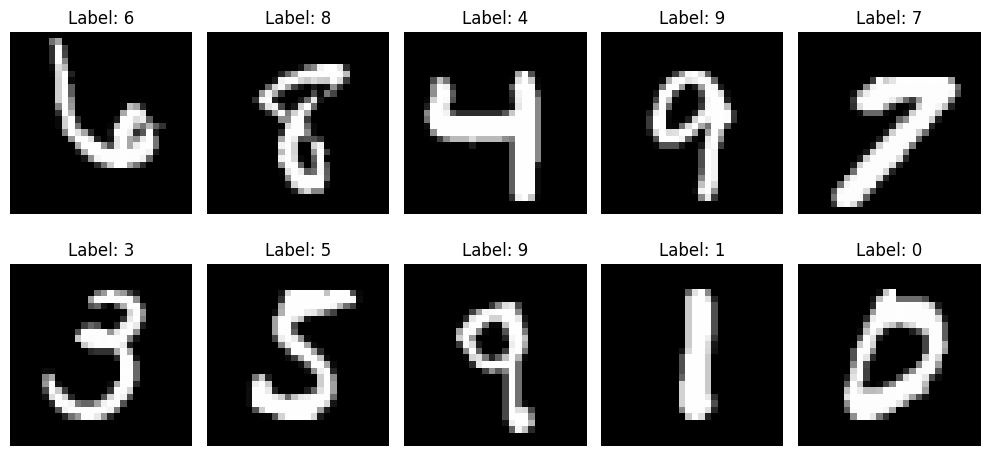

In [12]:
# Visualize sample digits
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for idx, ax in enumerate(axes.ravel()):
    ax.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y_train[idx]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Save reusable split artifacts
project_root = Path.cwd().parent
artifact_dir = project_root / 'results' / 'metrics'
artifact_dir.mkdir(parents=True, exist_ok=True)

artifact_path = artifact_dir / 'mnist_splits.npz'
np.savez_compressed(
    artifact_path,
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    X_train_std=X_train_std,
    X_val_std=X_val_std,
    X_test_std=X_test_std,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
)

print(f'Saved preprocessed artifacts to: {artifact_path}')

Saved preprocessed artifacts to: /Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs/MS_courses/CSIT_598_MachineLear/Assignments/project/results/metrics/mnist_splits.npz
